<a href="https://colab.research.google.com/github/springboardmentor1077k-prog/Vision-Extract-Isolation/blob/shivateja/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

drive_path = "/content/drive/MyDrive/coco_data"
local_val = os.path.join(drive_path, "val2017")
local_ann = os.path.join(drive_path, "annotations")

os.makedirs(drive_path, exist_ok=True)

if not (os.path.exists(local_val) and os.path.exists(local_ann)):
    print("⚠️ COCO dataset not found in Drive — downloading once...")

    # Create folders
    !mkdir -p val2017 annotations

    # Download val2017 images
    !wget -q http://images.cocodataset.org/zips/val2017.zip
    !unzip -q val2017.zip -d val2017

    # Download annotations
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip -d annotations

    # Copy both folders to Drive for future use
    !cp -r val2017 $drive_path/
    !cp -r annotations $drive_path/
    print("✅ Download complete and saved to Drive!")
else:
    print("✅ COCO dataset already exists in Drive — using that version.")

IMG_DIR = local_val
ANN_DIR = local_ann

print("Image path:", IMG_DIR)
print("Annotation path:", ANN_DIR)


Mounted at /content/drive
✅ COCO dataset already exists in Drive — using that version.
Image path: /content/drive/MyDrive/coco_data/val2017
Annotation path: /content/drive/MyDrive/coco_data/annotations


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
model.load_state_dict(torch.load("/content/drive/MyDrive/unet_trained.pth"))


## Evaluation metrics

Using device: cuda
loading annotations into memory...
Done (t=2.65s)
creating index...
index created!
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
✅ Loaded previous weights successfully! Continuing training...
Epoch [1/5] - Loss: 0.5013
Epoch [2/5] - Loss: 0.4925
Epoch [3/5] - Loss: 0.4823
Epoch [4/5] - Loss: 0.4784
Epoch [5/5] - Loss: 0.4732
✅ Model updated and saved successfully!

IoU Scores: [0.05813954025506973, 0.6730458736419678, 0.5355010628700256, 0.5492389798164368, 0.25607064366340637]
Dice Scores: [0.10989011824131012, 0.804575502872467, 0.6974935531616211, 0.709043562412262, 0.40773287415504456]
Average IoU: 0.41439922004938123
Average Dice: 0.5457471221685409


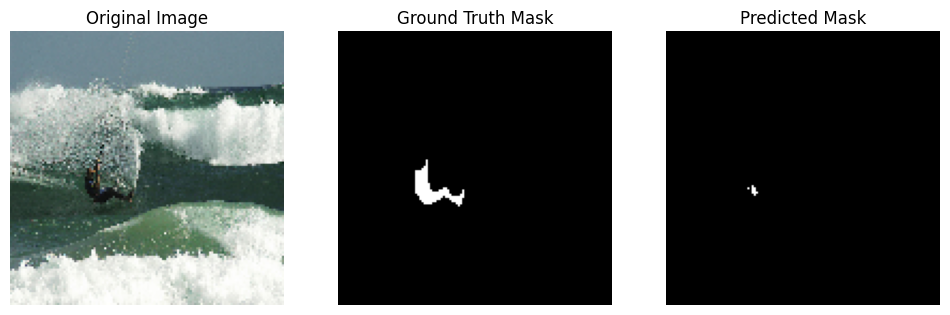

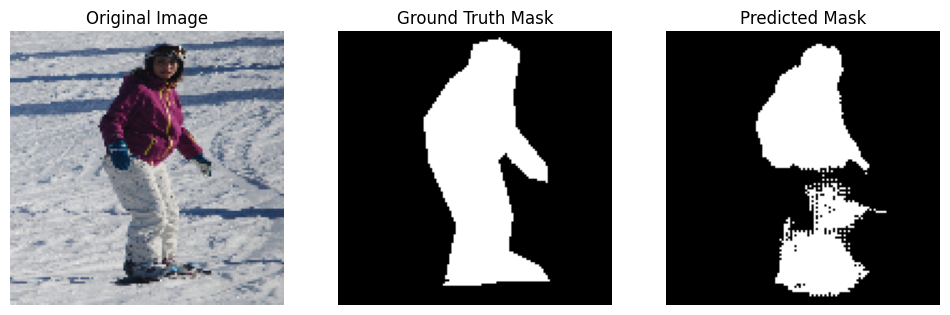

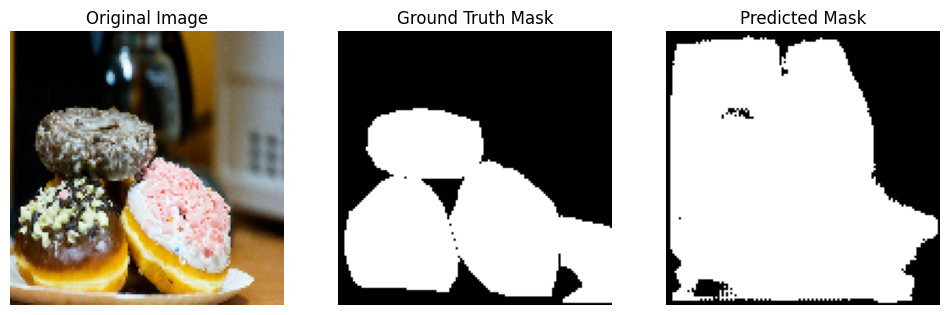

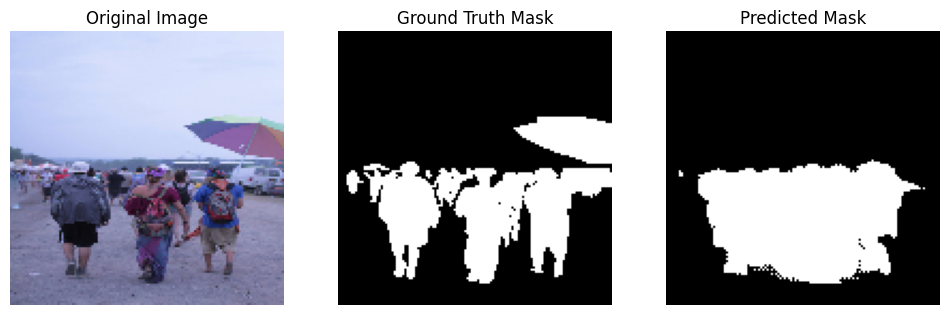

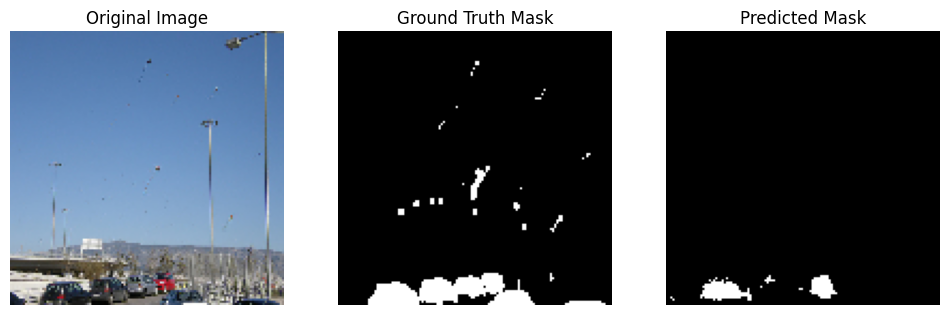

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CocoDetection
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import os, cv2
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"
coco_root = "drive/MyDrive/coco_data/val2017/val2017"
coco_ann = "drive/MyDrive/coco_data/annotations/annotations/instances_val2017.json"


class COCOSegmentation(Dataset):
    def __init__(self, root, annFile, target_size=(128, 128), max_images=None):
        super().__init__()
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))

        if max_images:
            random.shuffle(self.ids)
            self.ids = self.ids[:max_images]

        self.root = root
        self.target_size = target_size

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = self.coco.loadImgs(img_id)[0]['file_name']

        img = plt.imread(os.path.join(self.root, path))
        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 4:
            img = img[:, :, :3]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        img = cv2.resize(img, self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        img = TF.to_tensor(img)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img, mask

    def __len__(self):
        return len(self.ids)

train_loader = DataLoader(
    COCOSegmentation(coco_root, coco_ann, max_images=500),
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    COCOSegmentation(coco_root, coco_ann, max_images=100),
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return self.output_layer(d1)

model = UNet().to(device)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Loaded previous weights successfully! Continuing training...")
else:
    print("⚠️ No existing model found. Training from scratch.")

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), MODEL_PATH)
print("✅ Model updated and saved successfully!")

def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_coef(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

model.eval()
ious, dices = [], []
sample_imgs = []

for i, (img, mask) in enumerate(val_loader):
    if i == 5: break
    img, mask = img.to(device), mask.to(device)
    with torch.no_grad():
        output = model(img)
    iou = iou_score(output, mask)
    dice = dice_coef(output, mask)
    ious.append(iou.item()); dices.append(dice.item())
    sample_imgs.append((img.cpu(), mask.cpu(), output.cpu()))

print("\nIoU Scores:", ious)
print("Dice Scores:", dices)
print("Average IoU:", np.mean(ious))
print("Average Dice:", np.mean(dices))

for i, (img, mask, pred) in enumerate(sample_imgs):
    pred = (torch.sigmoid(pred) > 0.5).float()
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img[0].permute(1,2,0))
    plt.title("Original Image"); plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(mask[0].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask"); plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(pred[0].squeeze(), cmap='gray')
    plt.title("Predicted Mask"); plt.axis('off')
    plt.show()


## Post processing techniques

Using device: cpu
loading annotations into memory...
Done (t=2.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
✅ Loaded previous weights successfully! Continuing training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


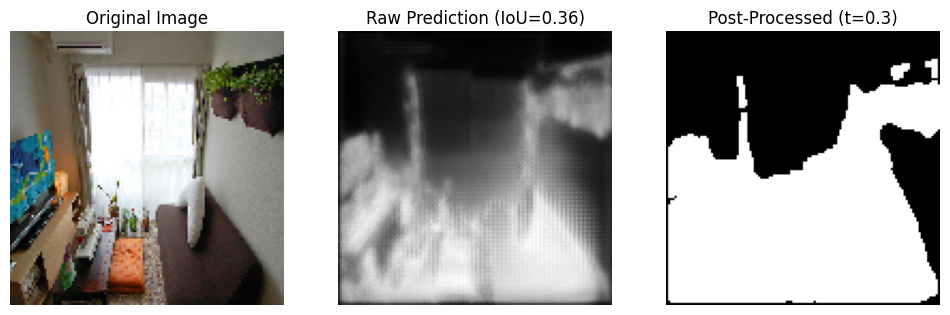

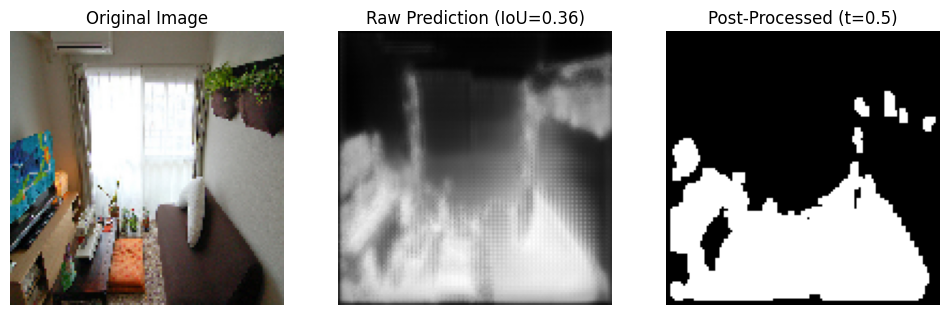

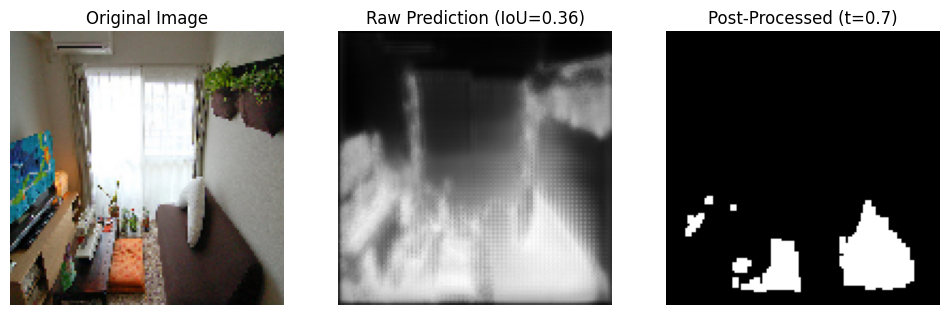

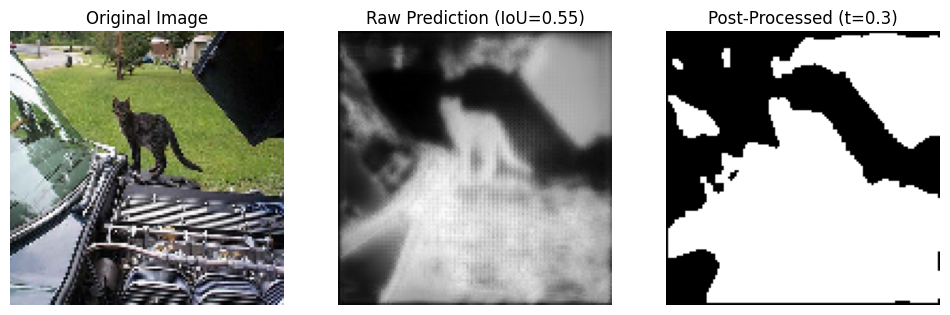

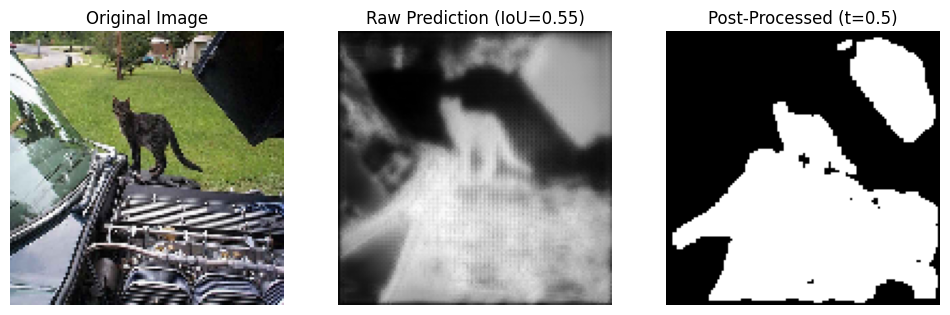

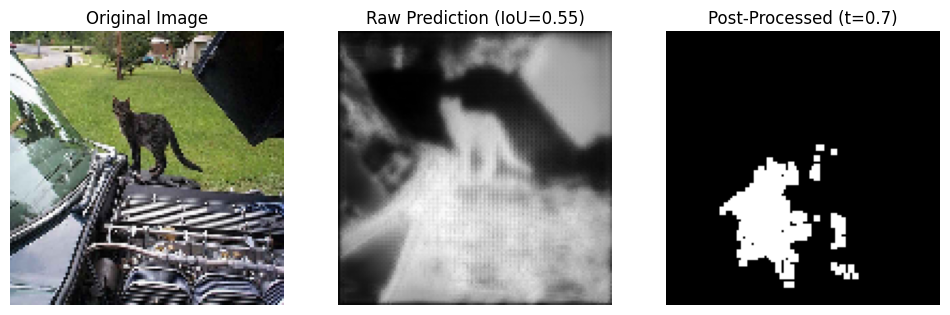

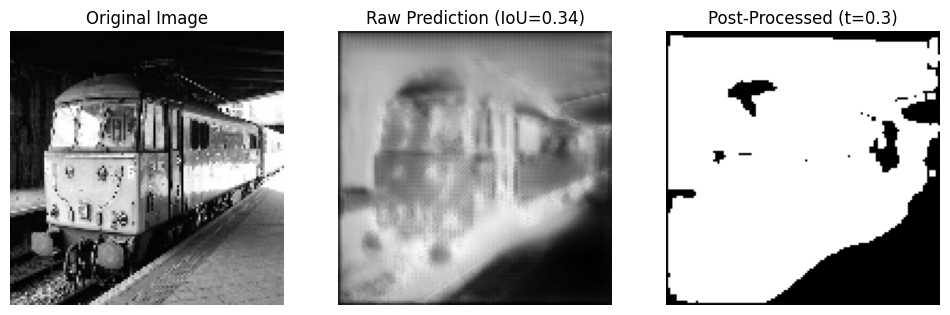

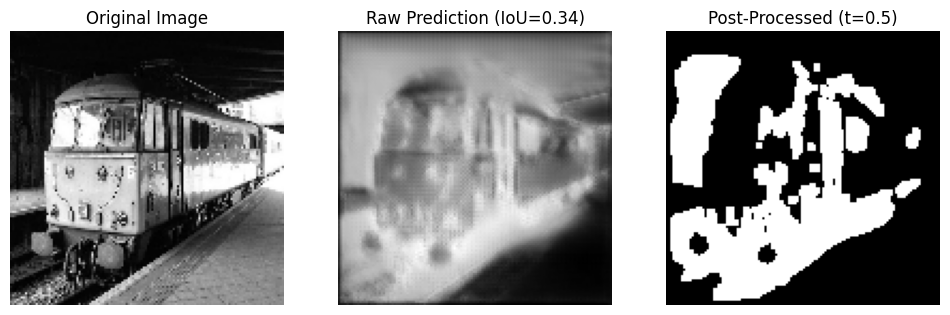

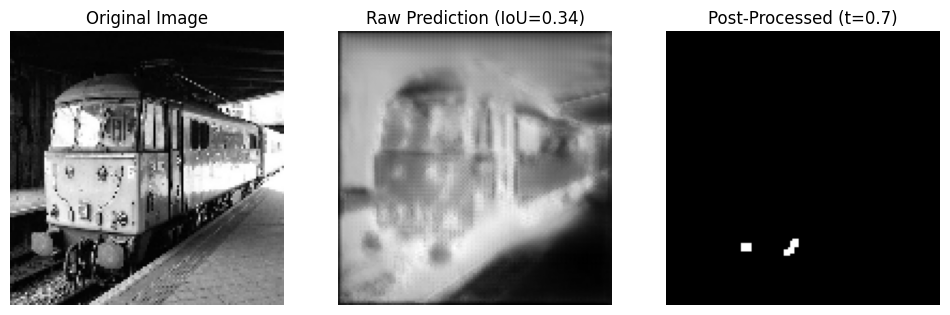

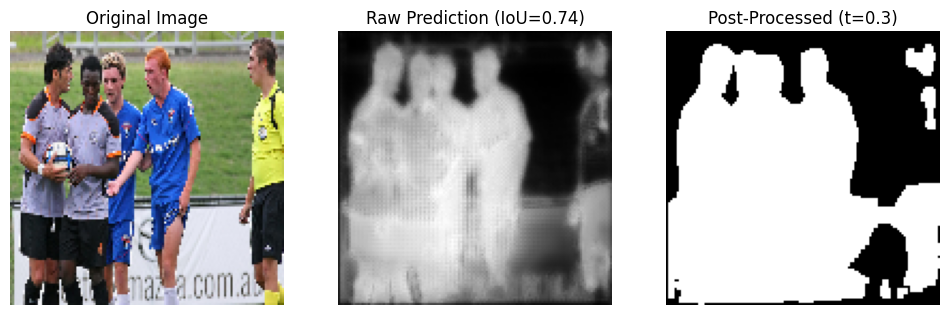

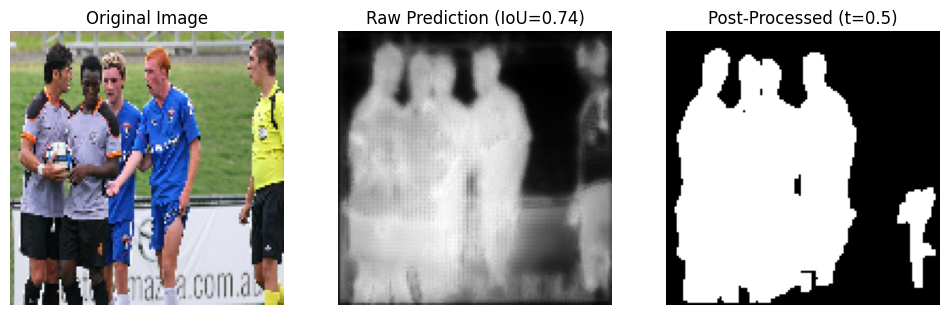

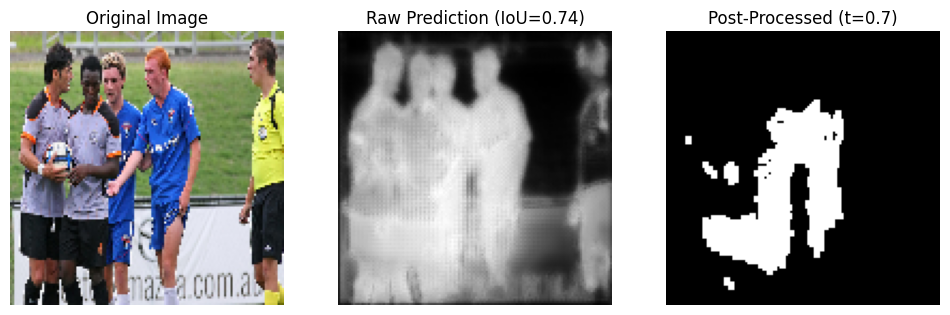

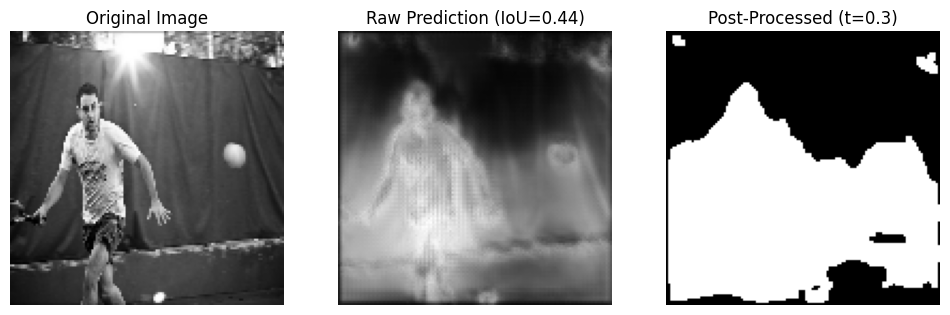

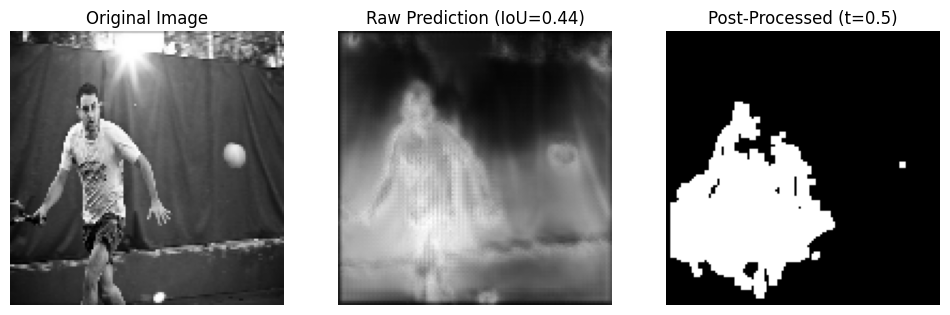

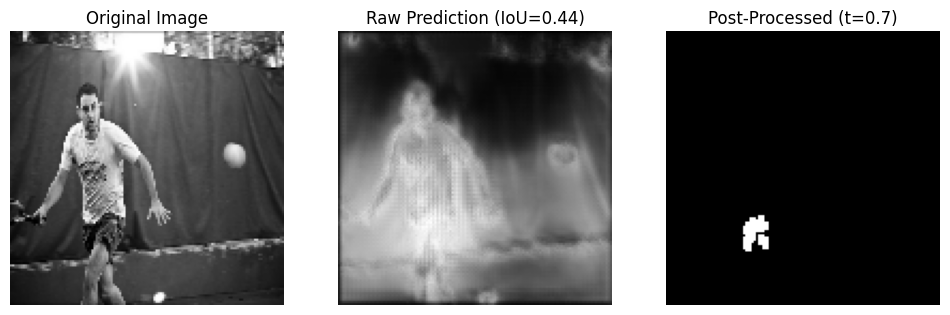

Average Raw IoU: 0.48513426184654235
Average Raw Dice: 0.6408671140670776
Average Post-Processed IoU: 0.36965709173431
Average Post-Processed Dice: 0.5045845684284965


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CocoDetection
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import os, cv2
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"
coco_root = "drive/MyDrive/coco_data/val2017/val2017"
coco_ann = "drive/MyDrive/coco_data/annotations/annotations/instances_val2017.json"


class COCOSegmentation(Dataset):
    def __init__(self, root, annFile, target_size=(128, 128), max_images=None):
        super().__init__()
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))

        if max_images:
            random.shuffle(self.ids)
            self.ids = self.ids[:max_images]

        self.root = root
        self.target_size = target_size

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = self.coco.loadImgs(img_id)[0]['file_name']

        img = plt.imread(os.path.join(self.root, path))
        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 4:
            img = img[:, :, :3]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        img = cv2.resize(img, self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        img = TF.to_tensor(img)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img, mask

    def __len__(self):
        return len(self.ids)

train_loader = DataLoader(
    COCOSegmentation(coco_root, coco_ann, max_images=500),
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    COCOSegmentation(coco_root, coco_ann, max_images=100),
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return self.output_layer(d1)

model = UNet().to(device)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Loaded previous weights successfully! Continuing training...")
else:
    print("⚠️ No existing model found. Training from scratch.")

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_coef(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def post_process_mask(mask, threshold=0.5, kernel_size=3, operation="open"):

    mask = torch.sigmoid(mask).cpu().numpy()[0]
    mask = (mask > threshold).astype(np.uint8) * 255

    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    if operation == "open":
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    elif operation == "close":
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    elif operation == "dilate":
        mask = cv2.dilate(mask, kernel, iterations=1)
    elif operation == "erode":
        mask = cv2.erode(mask, kernel, iterations=1)

    mask = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0)
    return mask

# Evaluation
model.eval()
raw_ious, raw_dices, post_ious, post_dices = [], [], [], []
thresholds = [0.3, 0.5, 0.7]

for i, (img, mask) in enumerate(val_loader):
    if i >= 5:  # evaluate on 5 samples
        break
    img, mask = img.to(device), mask.to(device)
    with torch.no_grad():
        output = model(img)

    # Raw metrics
    raw_iou = iou_score(output, mask)
    raw_dice = dice_coef(output, mask)
    raw_ious.append(raw_iou.item())
    raw_dices.append(raw_dice.item())

    # Try different thresholds
    for t in thresholds:
        post_mask = post_process_mask(output[0], threshold=t, kernel_size=3, operation="open")
        post_iou = iou_score(post_mask.unsqueeze(0).to(device), mask)
        post_dice = dice_coef(post_mask.unsqueeze(0).to(device), mask)
        post_ious.append(post_iou.item())
        post_dices.append(post_dice.item())

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img[0].permute(1, 2, 0).cpu())
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(torch.sigmoid(output[0][0]).cpu(), cmap='gray')
        plt.title(f"Raw Prediction (IoU={raw_iou:.2f})")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(post_mask[0], cmap='gray')
        plt.title(f"Post-Processed (t={t})")
        plt.axis("off")

        plt.show()

print("Average Raw IoU:", np.mean(raw_ious))
print("Average Raw Dice:", np.mean(raw_dices))
print("Average Post-Processed IoU:", np.mean(post_ious))
print("Average Post-Processed Dice:", np.mean(post_dices))


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving sample1.jpg to sample1.jpg


In [ ]:
import os

print(os.path.getsize("drive/MyDrive/unet_trained.pth"))

124235263
